# Population-Linked Replacement-Dynamics Model by FSA

This notebook extends the current province-level calibrated model to the **FSA level**.

It keeps the same core logic:

- the **sales mix** is calibrated using the external registrations dataset,
- the **total fleet** follows a smooth, population-linked path,
- the **fleet stock** changes gradually through replacement dynamics.

## Why the FSA version needs extra care

At the province level, the data is relatively stable. At the FSA level, many postal areas have:

- low yearly entries,
- irregular technology shares,
- zero values for EVs or hybrids in early years,
- and noisy local fluctuations.

If we forecast every FSA independently from raw local growth rates, the model becomes unstable very quickly.

## New idea for the FSA model

We use a **hierarchical** approach.

### Province-level signals

The province-level model provides:

- the calibrated future sales-share path,
- the population-linked total fleet path,
- and the provincial turnover reference.

### FSA-level adjustment

Each FSA keeps its own local history, but its forecast is **shrunk toward the provincial benchmark**.

That means:

- large FSAs with many yearly entries keep more local behavior,
- small FSAs with sparse data rely more on the provincial signal.

## Main modeling structure

1. Build the province-level calibrated benchmark.
2. Build historical FSA fleet, entry, and exit tables.
3. Estimate each FSA's average yearly entries.
4. Convert that data volume into a **shrinkage weight**.
5. Forecast each FSA's future sales share as:
   - local trend, plus
   - shrinkage toward the provincial calibrated path.
6. Forecast each FSA's total fleet by allocating the provincial population-linked fleet across FSAs using stable FSA fleet shares.
7. Rebuild each FSA's fleet through entries and exits.

## Interpretation

This notebook is designed to answer the practical question:

> How can we apply the same replacement-dynamics idea at the FSA level without letting sparse local data create unrealistic EV adoption paths?

The answer is:

- use the **province** for stability,
- use the **FSA** for local variation,
- and control the balance with a shrinkage rule based on local sample size.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_DIR = Path('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model')
CACHE_DIR = PROJECT_DIR / '.cache'
DATASET_DIR = PROJECT_DIR / 'datasets'
EXTERNAL_FILE = DATASET_DIR / 'Fig1-NMVRegist.xlsx'
POPULATION_REFERENCE_FILE = DATASET_DIR / '1710000901-eng.csv'

## Settings

These parameters control the FSA forecast.

### Main controls

- `TARGET_FSA`
  The postal area used for the detailed diagnostic plots.

- `FORECAST_END_YEAR`
  Final projection year.

- `CALIBRATION_WINDOW`
  Controls whether the sales-share calibration uses the full external history or only recent years.

- `POPULATION_GROWTH_WINDOW`
  Controls which years in the population reference are used to estimate long-run net fleet growth.

- `TURNOVER_MODEL`
  Controls how provincial turnover is projected.

- `SHRINKAGE_K`
  Controls how aggressively local FSAs are shrunk toward the provincial benchmark.

### Shrinkage interpretation

The notebook uses:

`w_fsa = avg_entries_per_year / (avg_entries_per_year + SHRINKAGE_K)`

So:

- large `avg_entries_per_year` means more local influence,
- small `avg_entries_per_year` means more provincial influence.

In [2]:
ENTRY_FLAG = 'Entrant'
EXIT_FLAG = 'Sortant'
TARGET_FSA = 'H3A'
FORECAST_END_YEAR = 2035

CALIBRATION_WINDOW = 'recent'  # 'recent' or 'full'
RECENT_START_YEAR = 2021
POPULATION_GROWTH_WINDOW = (2021, 2026)

TURNOVER_MODEL = 'average'  # 'average' or 'linear'
TURNOVER_RATE_CLIP = (0.03, 0.12)
SHARE_DELTA_CLIP = (-0.05, 0.05)
MAX_ELECTRIC_ENTRY_SHARE = 0.45
DAMPING_END_FACTOR = 0.35

SHRINKAGE_K = 500.0
MIN_AVG_ENTRIES_FOR_FLAG = 100.0
FSA_SHARE_WINDOW = 3

vehicle_cols = ['electric', 'hev_sedan', 'hev_suv', 'ice_sedan', 'ice_suv', 'ice_van/pickup']
quarter_order = ['T1', 'T2', 'T3', 'T4']

## Step 1: Build the Province-Level External Sales Benchmark

We use the same external registrations file as in the province-level notebook.

The mapping into the model categories is:

- `electric`: total battery electric registrations
- `hev_sedan`: passenger-car plug-in hybrid + hybrid
- `hev_suv`: multi-purpose plug-in hybrid + hybrid
- `ice_sedan`: passenger-car gasoline + diesel + other fuels
- `ice_suv`: multi-purpose gasoline + diesel + other fuels
- `ice_van/pickup`: residual share

This provides the province-level market benchmark that every FSA can borrow from.

In [3]:
raw_external = pd.read_excel(EXTERNAL_FILE, sheet_name='Sheet 1', header=None)

years = raw_external.iloc[0, 2:].ffill().astype(int).tolist()
quarters = raw_external.iloc[1, 2:].tolist()

records = []
current_body_class = None
for row_idx in range(2, len(raw_external)):
    row = raw_external.iloc[row_idx]
    if pd.notna(row[0]):
        current_body_class = str(row[0]).strip()

    fuel_type = row[1]
    if pd.isna(fuel_type):
        continue

    fuel_type = str(fuel_type).strip()
    values = row.iloc[2:].tolist()
    for year, quarter, value in zip(years, quarters, values):
        if pd.isna(value):
            continue
        records.append({
            'body_class': current_body_class,
            'fuel_type': fuel_type,
            'year': int(year),
            'quarter': str(quarter),
            'registrations': float(value),
        })

external_long = pd.DataFrame(records)
quarterly_cube = (
    external_long.pivot_table(
        index=['year', 'quarter'],
        columns=['body_class', 'fuel_type'],
        values='registrations',
        aggfunc='sum',
        fill_value=0,
    )
    .sort_index()
)
quarterly_cube.columns = pd.MultiIndex.from_tuples(quarterly_cube.columns)

def qcol(body_class, fuel_type):
    if (body_class, fuel_type) in quarterly_cube.columns:
        return quarterly_cube[(body_class, fuel_type)]
    return pd.Series(0.0, index=quarterly_cube.index)

external_mapped_counts = pd.DataFrame(index=quarterly_cube.index)
external_mapped_counts['electric'] = qcol('Total, vehicle type', 'Battery electric')
external_mapped_counts['hev_sedan'] = qcol('Passenger cars', 'Plug-in hybrid electric') + qcol('Passenger cars', 'Hybrid electric')
external_mapped_counts['hev_suv'] = qcol('Multi-purpose vehicles', 'Plug-in hybrid electric') + qcol('Multi-purpose vehicles', 'Hybrid electric')
external_mapped_counts['ice_sedan'] = qcol('Passenger cars', 'Gasoline') + qcol('Passenger cars', 'Diesel') + qcol('Passenger cars', 'Other fuel types')
external_mapped_counts['ice_suv'] = qcol('Multi-purpose vehicles', 'Gasoline') + qcol('Multi-purpose vehicles', 'Diesel') + qcol('Multi-purpose vehicles', 'Other fuel types')
external_mapped_counts['total_registrations'] = quarterly_cube.xs('Total, vehicle type', axis=1, level=0).sum(axis=1)
external_mapped_counts['ice_van/pickup'] = (
    external_mapped_counts['total_registrations']
    - external_mapped_counts[['electric', 'hev_sedan', 'hev_suv', 'ice_sedan', 'ice_suv']].sum(axis=1)
).clip(lower=0)

external_mapped_counts = external_mapped_counts.reset_index()
external_mapped_counts['quarter_num'] = external_mapped_counts['quarter'].map({q: i + 1 for i, q in enumerate(quarter_order)})

external_trailing = external_mapped_counts.copy().sort_values(['year', 'quarter_num']).reset_index(drop=True)
for col in vehicle_cols + ['total_registrations']:
    external_trailing[f'{col}_trailing4'] = external_trailing[col].rolling(4, min_periods=4).sum()

external_trailing_shares = external_trailing[['year', 'quarter']].copy()
for col in vehicle_cols:
    external_trailing_shares[f'{col}_trailing4_share'] = external_trailing[f'{col}_trailing4'] / external_trailing['total_registrations_trailing4']

external_annual_counts = external_mapped_counts.groupby('year')[vehicle_cols + ['total_registrations']].sum()
external_annual_benchmark = external_annual_counts[vehicle_cols].div(external_annual_counts['total_registrations'], axis=0)
latest_trailing_row = external_trailing_shares.loc[(external_trailing_shares['year'] == 2025) & (external_trailing_shares['quarter'] == 'T1')].iloc[0]
for col in vehicle_cols:
    external_annual_benchmark.loc[2025, col] = float(latest_trailing_row[f'{col}_trailing4_share'])

external_annual_benchmark.loc[2017:2025]

,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
year,,,,,,
2017,0.004459,0.010761,0.005718,0.295165,0.414240,0.269658
2018,0.011430,0.013439,0.009900,0.267113,0.441770,0.256347
2019,0.018401,0.016904,0.013350,0.226667,0.463600,0.261079
2020,0.025262,0.013119,0.022694,0.177536,0.475213,0.286175
2021,0.035908,0.015508,0.038214,0.164165,0.498594,0.247611
2022,0.065177,0.012913,0.043929,0.137938,0.480234,0.259808
2023,0.083770,0.015194,0.079522,0.115300,0.458924,0.247289
2024,0.109166,0.018793,0.092923,0.100463,0.452618,0.226036
2025,0.103438,0.021129,0.097522,0.095511,0.452830,0.229572


## Step 2: Load the Cached SAAQ Data and Build Province-Level Controls

We now rebuild the province-level controls used by the FSA model:

- province-level historical fleet,
- province-level entry and exit shares,
- population-linked provincial total fleet path,
- and the calibrated future sales-share path.

The FSA model will borrow these as the stable reference.

In [4]:
fleet_counts = pd.read_pickle(CACHE_DIR / 'saq_vehicle_counts.pkl')
entry_counts = pd.read_pickle(CACHE_DIR / 'saq_entry_counts.pkl')
entry_full = pd.read_pickle(CACHE_DIR / 'saq_entry_full.pkl')

prov_fleet = (
    fleet_counts.pivot_table(index='AnneeSAAQ', columns='vehicle_type', values='count', aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
prov_fleet['total_vehicles'] = prov_fleet.sum(axis=1)

prov_entry = (
    entry_counts.pivot_table(index='AnneeSAAQ', columns='vehicle_type', values=ENTRY_FLAG, aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
prov_entry['total_entries'] = prov_entry.sum(axis=1)

prov_exit = (
    entry_full.pivot_table(index='AnneeSAAQ', columns='vehicle_type', values=EXIT_FLAG, aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
prov_exit['total_exits'] = prov_exit.sum(axis=1)

prov_entry_share_hist = prov_entry[vehicle_cols].div(prov_entry['total_entries'].replace(0, np.nan), axis=0).fillna(0)
prov_exit_share_hist = prov_exit[vehicle_cols].div(prov_exit['total_exits'].replace(0, np.nan), axis=0).fillna(0)

prov_entry_share_delta = prov_entry_share_hist.diff().replace([np.inf, -np.inf], 0).fillna(0).clip(*SHARE_DELTA_CLIP)
prov_exit_share_delta = prov_exit_share_hist.diff().replace([np.inf, -np.inf], 0).fillna(0).clip(*SHARE_DELTA_CLIP)
avg_prov_exit_share_delta = prov_exit_share_delta.mean().reindex(vehicle_cols).fillna(0)

flow_rates = pd.DataFrame(index=prov_fleet.index)
flow_rates['fleet_prev_year'] = prov_fleet['total_vehicles'].shift(1)
flow_rates['entry_rate'] = (prov_entry['total_entries'] / flow_rates['fleet_prev_year']).replace([np.inf, -np.inf], np.nan)
flow_rates['exit_rate'] = (prov_exit['total_exits'] / flow_rates['fleet_prev_year']).replace([np.inf, -np.inf], np.nan)
flow_source = flow_rates.dropna().copy()

last_observed_year = int(prov_fleet.index.max())
future_years = list(range(last_observed_year + 1, FORECAST_END_YEAR + 1))

population_raw = pd.read_csv(POPULATION_REFERENCE_FILE, skiprows=7)
population_quebec = population_raw[population_raw['Geography'] == 'Quebec'].copy()
population_quebec = population_quebec.drop(columns=[c for c in population_quebec.columns if str(c).startswith('Unnamed')], errors='ignore')
pop_row = population_quebec.iloc[0].drop(labels=['Geography'])
pop_series = pd.to_numeric(pop_row.astype(str).str.replace(',', '', regex=False), errors='coerce').dropna()
population_q1 = {}
for col, value in pop_series.items():
    col = str(col)
    if col.startswith('Q1 '):
        population_q1[int(col.split()[-1])] = float(value)
population_q1 = pd.Series(population_q1).sort_index()
population_growth = population_q1.pct_change()
start_year, end_year = POPULATION_GROWTH_WINDOW
reference_population_growth = float(population_growth.loc[start_year:end_year].mean())
future_population_growth = pd.Series(index=future_years, dtype=float)
for year in future_years:
    if year in population_growth.index and pd.notna(population_growth.loc[year]):
        future_population_growth.loc[year] = float(population_growth.loc[year])
    else:
        future_population_growth.loc[year] = reference_population_growth

def fit_turnover_projection(series, future_years, clip_bounds):
    hist = series.dropna().copy()
    if len(hist) < 2:
        return pd.Series({year: float(hist.iloc[-1]) if len(hist) else 0.0 for year in future_years})
    x = hist.index.to_numpy(dtype=float)
    y = hist.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    pred = pd.Series({year: intercept + slope * year for year in future_years}, dtype=float)
    return pred.clip(lower=clip_bounds[0], upper=clip_bounds[1])

if TURNOVER_MODEL == 'linear':
    province_turnover_rate = fit_turnover_projection(flow_source['entry_rate'], future_years, TURNOVER_RATE_CLIP)
else:
    province_turnover_rate = pd.Series(flow_source['entry_rate'].mean(), index=future_years, dtype=float).clip(*TURNOVER_RATE_CLIP)

province_target_total_fleet = pd.Series(index=[last_observed_year] + future_years, dtype=float)
province_target_total_fleet.loc[last_observed_year] = float(prov_fleet.loc[last_observed_year, 'total_vehicles'])
for year in future_years:
    province_target_total_fleet.loc[year] = province_target_total_fleet.loc[year - 1] * (1 + float(future_population_growth.loc[year]))

population_reference_summary = pd.DataFrame({'population_q1': population_q1, 'population_growth': population_growth}).loc[2015:2026]
population_reference_summary.tail()

,population_q1,population_growth
2022,8613282.0,0.007335
2023,8742975.0,0.015057
2024,8909038.0,0.018994
2025,9043463.0,0.015089
2026,9033887.0,-0.001059


## Step 3: Build the Province-Level Calibrated Future Sales Path

The FSA model needs one province-level future sales-share path that acts as the stable reference.

This path is the same logic as in the province notebook:

- use the external benchmark directly for `2021` to `2025`,
- use damped annual share changes after `2025`,
- clip EV share to a reasonable ceiling,
- keep all category shares summing to 1.

In [5]:
if CALIBRATION_WINDOW == 'recent':
    calibration_source = external_annual_benchmark.loc[RECENT_START_YEAR:2025].copy()
else:
    calibration_source = external_annual_benchmark.loc[2017:2025].copy()

benchmark_share_delta = calibration_source[vehicle_cols].diff().replace([np.inf, -np.inf], 0).fillna(0).clip(*SHARE_DELTA_CLIP)
avg_benchmark_share_delta = benchmark_share_delta.mean().reindex(vehicle_cols).fillna(0)

province_entry_share_future = prov_entry_share_hist.copy()
for year in range(2021, min(2025, FORECAST_END_YEAR) + 1):
    province_entry_share_future.loc[year, vehicle_cols] = external_annual_benchmark.loc[year, vehicle_cols].astype(float)

current_external_share = external_annual_benchmark.loc[2025, vehicle_cols].astype(float).copy()
for position, year in enumerate(range(2026, FORECAST_END_YEAR + 1), start=1):
    damping = 1 - (1 - DAMPING_END_FACTOR) * (position / max(1, FORECAST_END_YEAR - 2025))
    next_share = (current_external_share + avg_benchmark_share_delta * damping).clip(lower=0)
    next_share = next_share / next_share.sum() if next_share.sum() > 0 else current_external_share.copy()
    next_share['electric'] = min(float(next_share['electric']), MAX_ELECTRIC_ENTRY_SHARE)
    non_electric = next_share.drop('electric')
    if non_electric.sum() > 0:
        next_share.loc[non_electric.index] = non_electric * ((1 - next_share['electric']) / non_electric.sum())
    province_entry_share_future.loc[year, vehicle_cols] = next_share
    current_external_share = next_share.copy()

province_exit_share_future = prov_exit_share_hist.copy()
current_exit_share = prov_exit_share_hist.loc[last_observed_year, vehicle_cols].astype(float).copy()
current_exit_share = current_exit_share / current_exit_share.sum() if current_exit_share.sum() > 0 else pd.Series(1 / len(vehicle_cols), index=vehicle_cols)
for year in future_years:
    next_exit_share = (current_exit_share + avg_prov_exit_share_delta).clip(lower=0)
    next_exit_share = next_exit_share / next_exit_share.sum() if next_exit_share.sum() > 0 else current_exit_share.copy()
    province_exit_share_future.loc[year, vehicle_cols] = next_exit_share
    current_exit_share = next_exit_share.copy()

province_entry_share_future.loc[2021:2035, vehicle_cols].tail()

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2031,0.166038,0.026339,0.152499,0.031868,0.410406,0.212850
2032,0.173399,0.026951,0.158964,0.024385,0.405417,0.210884
2033,0.179882,0.027491,0.164657,0.017794,0.401024,0.209152
2034,0.185487,0.027957,0.169580,0.012096,0.397225,0.207655
2035,0.190214,0.028351,0.173731,0.007290,0.394022,0.206392


## Step 4: Build Historical FSA Tables

We now move to the local level.

For each FSA and year we need:

- fleet counts by vehicle type,
- entry counts by vehicle type,
- exit counts by vehicle type,
- total fleet,
- total entries,
- total exits.

These local tables are the starting point for the shrinkage-based forecast.

In [6]:
fsa_fleet = (
    fleet_counts.pivot_table(index=['fsa', 'AnneeSAAQ'], columns='vehicle_type', values='count', aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
fsa_fleet['total_vehicles'] = fsa_fleet.sum(axis=1)

fsa_entry = (
    entry_counts.pivot_table(index=['fsa', 'AnneeSAAQ'], columns='vehicle_type', values=ENTRY_FLAG, aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
fsa_entry['total_entries'] = fsa_entry.sum(axis=1)

fsa_exit = (
    entry_full.pivot_table(index=['fsa', 'AnneeSAAQ'], columns='vehicle_type', values=EXIT_FLAG, aggfunc='sum', fill_value=0)
    .reindex(columns=vehicle_cols, fill_value=0)
    .sort_index()
)
fsa_exit['total_exits'] = fsa_exit.sum(axis=1)

pd.DataFrame({
    'n_fsas': [fsa_fleet.index.get_level_values('fsa').nunique()],
    'year_min': [fsa_fleet.index.get_level_values('AnneeSAAQ').min()],
    'year_max': [fsa_fleet.index.get_level_values('AnneeSAAQ').max()],
    'rows_fleet': [len(fsa_fleet)],
    'rows_entry': [len(fsa_entry)],
    'rows_exit': [len(fsa_exit)],
})

,n_fsas,year_min,year_max,rows_fleet,rows_entry,rows_exit
0,526,2013,2020,3731,3731,3731


## Step 5: Define the FSA Shrinkage-Based Forecast Function

This is the core FSA model.

For one FSA, the function does the following:

1. build historical fleet, entry, and exit tables,
2. estimate average yearly entries,
3. convert that into a shrinkage weight,
4. project local sales shares using local share changes,
5. shrink those local shares toward the calibrated province-level path,
6. build a target local total fleet from a stable FSA share of the province total,
7. use turnover plus target total to infer exits,
8. rebuild local fleet counts and market shares.

## Stable local fleet totals

We do **not** let each FSA independently extrapolate its total fleet with a noisy linear fit.

Instead:

- each FSA gets a stable share of the province total,
- estimated from the last few observed years,
- and that share is applied to the province-level population-linked total fleet.

That keeps the local stock path realistic and ensures all FSA totals add back up to the province.

In [7]:
def run_fsa_population_linked_model(
    fsa,
    fsa_fleet,
    fsa_entry,
    fsa_exit,
    province_entry_share_future,
    province_exit_share_future,
    province_target_total_fleet,
    province_turnover_rate,
    vehicle_cols,
    forecast_end_year,
    share_delta_clip,
    shrinkage_k,
    fsa_share_window,
):
    fleet_hist = fsa_fleet.xs(fsa, level='fsa').copy().sort_index()
    entry_hist = fsa_entry.xs(fsa, level='fsa').copy().sort_index()
    exit_hist = fsa_exit.xs(fsa, level='fsa').copy().sort_index()

    historical_years = list(range(int(prov_fleet.index.min()), last_observed_year + 1))
    fleet_hist = fleet_hist.reindex(historical_years, fill_value=0)
    entry_hist = entry_hist.reindex(historical_years, fill_value=0)
    exit_hist = exit_hist.reindex(historical_years, fill_value=0)
    fleet_hist['total_vehicles'] = fleet_hist[vehicle_cols].sum(axis=1)
    entry_hist['total_entries'] = entry_hist[vehicle_cols].sum(axis=1)
    exit_hist['total_exits'] = exit_hist[vehicle_cols].sum(axis=1)

    local_entry_share_hist = entry_hist[vehicle_cols].div(entry_hist['total_entries'].replace(0, np.nan), axis=0).fillna(0)
    local_exit_share_hist = exit_hist[vehicle_cols].div(exit_hist['total_exits'].replace(0, np.nan), axis=0).fillna(0)
    local_entry_share_delta = local_entry_share_hist.diff().replace([np.inf, -np.inf], 0).fillna(0).clip(*share_delta_clip)
    local_exit_share_delta = local_exit_share_hist.diff().replace([np.inf, -np.inf], 0).fillna(0).clip(*share_delta_clip)

    avg_entries_per_year = float(entry_hist['total_entries'].mean()) if len(entry_hist) else 0.0
    shrinkage_weight = avg_entries_per_year / (avg_entries_per_year + shrinkage_k) if avg_entries_per_year >= 0 else 0.0

    avg_local_entry_delta = local_entry_share_delta.mean().reindex(vehicle_cols).fillna(0)
    avg_local_exit_delta = local_exit_share_delta.mean().reindex(vehicle_cols).fillna(0)

    local_sales_share_future = local_entry_share_hist.copy()
    current_local_share = local_entry_share_hist.loc[last_observed_year, vehicle_cols].astype(float).copy()
    current_local_share = current_local_share / current_local_share.sum() if current_local_share.sum() > 0 else province_entry_share_future.loc[last_observed_year, vehicle_cols].astype(float)
    for year in future_years:
        next_local = (current_local_share + avg_local_entry_delta).clip(lower=0)
        next_local = next_local / next_local.sum() if next_local.sum() > 0 else current_local_share.copy()
        local_sales_share_future.loc[year, vehicle_cols] = next_local
        current_local_share = next_local.copy()

    fsa_sales_share_future = province_entry_share_future.copy()[vehicle_cols].loc[future_years].copy()
    for year in future_years:
        province_row = province_entry_share_future.loc[year, vehicle_cols].astype(float)
        local_row = local_sales_share_future.loc[year, vehicle_cols].astype(float)
        blended = shrinkage_weight * local_row + (1 - shrinkage_weight) * province_row
        blended = blended.clip(lower=0)
        blended = blended / blended.sum() if blended.sum() > 0 else province_row.copy()
        fsa_sales_share_future.loc[year, vehicle_cols] = blended

    local_exit_share_future = local_exit_share_hist.copy()
    current_local_exit = local_exit_share_hist.loc[last_observed_year, vehicle_cols].astype(float).copy()
    current_local_exit = current_local_exit / current_local_exit.sum() if current_local_exit.sum() > 0 else province_exit_share_future.loc[last_observed_year, vehicle_cols].astype(float)
    for year in future_years:
        next_local_exit = (current_local_exit + avg_local_exit_delta).clip(lower=0)
        next_local_exit = next_local_exit / next_local_exit.sum() if next_local_exit.sum() > 0 else current_local_exit.copy()
        province_exit_row = province_exit_share_future.loc[year, vehicle_cols].astype(float)
        blended_exit = shrinkage_weight * next_local_exit + (1 - shrinkage_weight) * province_exit_row
        blended_exit = blended_exit.clip(lower=0)
        blended_exit = blended_exit / blended_exit.sum() if blended_exit.sum() > 0 else province_exit_row.copy()
        local_exit_share_future.loc[year, vehicle_cols] = blended_exit
        current_local_exit = next_local_exit.copy()

    province_hist_total = prov_fleet['total_vehicles']
    fsa_hist_total = fleet_hist['total_vehicles']
    common_years = sorted(set(fsa_hist_total.index).intersection(set(province_hist_total.index)))
    recent_share_years = common_years[-min(fsa_share_window, len(common_years)):]
    if recent_share_years:
        stable_fsa_share = float((fsa_hist_total.loc[recent_share_years] / province_hist_total.loc[recent_share_years]).mean())
    else:
        stable_fsa_share = 0.0

    fsa_target_total = pd.Series(index=[last_observed_year] + future_years, dtype=float)
    fsa_target_total.loc[last_observed_year] = float(fleet_hist.loc[last_observed_year, 'total_vehicles'])
    for year in future_years:
        fsa_target_total.loc[year] = max(float(province_target_total_fleet.loc[year]) * stable_fsa_share, 0.0)

    local_flow_rates = pd.DataFrame(index=fleet_hist.index)
    local_flow_rates['fleet_prev_year'] = fleet_hist['total_vehicles'].shift(1)
    local_flow_rates['entry_rate'] = (entry_hist['total_entries'] / local_flow_rates['fleet_prev_year']).replace([np.inf, -np.inf], np.nan)
    local_avg_entry_rate = float(local_flow_rates['entry_rate'].dropna().mean()) if len(local_flow_rates['entry_rate'].dropna()) else float(province_turnover_rate.mean())

    fsa_turnover_rate = pd.Series(index=future_years, dtype=float)
    for year in future_years:
        fsa_turnover_rate.loc[year] = shrinkage_weight * local_avg_entry_rate + (1 - shrinkage_weight) * float(province_turnover_rate.loc[year])
        fsa_turnover_rate.loc[year] = float(np.clip(fsa_turnover_rate.loc[year], TURNOVER_RATE_CLIP[0], TURNOVER_RATE_CLIP[1]))

    projected_counts = fleet_hist.copy()
    current_counts = projected_counts.loc[last_observed_year, vehicle_cols].astype(float).copy()
    projection_rows = []
    for year in future_years:
        current_total = float(current_counts.sum())
        turnover_rate = float(fsa_turnover_rate.loc[year])
        target_total = float(fsa_target_total.loc[year])
        entries = current_total * turnover_rate
        exits = max(current_total + entries - target_total, 0.0)
        additions = entries * fsa_sales_share_future.loc[year, vehicle_cols].astype(float)
        removals = exits * local_exit_share_future.loc[year, vehicle_cols].astype(float)
        next_counts = (current_counts + additions - removals).clip(lower=0)
        next_total = float(next_counts.sum())
        if next_total > 0 and target_total > 0:
            next_counts = next_counts * (target_total / next_total)
            next_total = float(next_counts.sum())
        projected_counts.loc[year, vehicle_cols] = next_counts
        projected_counts.loc[year, 'total_vehicles'] = next_total
        projection_rows.append({
            'year': year,
            'fsa': fsa,
            'shrinkage_weight': shrinkage_weight,
            'avg_entries_per_year': avg_entries_per_year,
            'stable_fsa_share': stable_fsa_share,
            'turnover_rate': turnover_rate,
            'entries': entries,
            'exits': exits,
            'target_total_vehicles': target_total,
            'total_vehicles': next_total,
        })
        current_counts = next_counts.copy()

    projected_market_share = projected_counts[vehicle_cols].div(projected_counts[vehicle_cols].sum(axis=1), axis=0).fillna(0)
    diagnostics = {
        'fsa': fsa,
        'avg_entries_per_year': avg_entries_per_year,
        'shrinkage_weight': shrinkage_weight,
        'stable_fsa_share': stable_fsa_share,
        'last_observed_total': float(fleet_hist.loc[last_observed_year, 'total_vehicles']),
        'projected_2035_total': float(projected_counts.loc[forecast_end_year, 'total_vehicles']) if forecast_end_year in projected_counts.index else np.nan,
    }

    sales_with_hist = pd.concat([
        local_entry_share_hist.loc[local_entry_share_hist.index <= last_observed_year, vehicle_cols],
        fsa_sales_share_future.loc[future_years, vehicle_cols],
    ])
    sales_with_hist = sales_with_hist[~sales_with_hist.index.duplicated(keep='last')].sort_index()

    return {
        'fleet_hist': fleet_hist,
        'entry_hist': entry_hist,
        'exit_hist': exit_hist,
        'sales_share_future': sales_with_hist,
        'projected_counts': projected_counts,
        'projected_market_share': projected_market_share,
        'projection_summary': pd.DataFrame(projection_rows),
        'diagnostics': diagnostics,
    }

## Step 6: Run the Model for One Selected FSA

This section is the detailed walkthrough for one postal area.

Use it to inspect whether the replacement logic, shrinkage, and population-linked stock path all make sense locally.

In [8]:
selected = run_fsa_population_linked_model(
    TARGET_FSA,
    fsa_fleet=fsa_fleet,
    fsa_entry=fsa_entry,
    fsa_exit=fsa_exit,
    province_entry_share_future=province_entry_share_future,
    province_exit_share_future=province_exit_share_future,
    province_target_total_fleet=province_target_total_fleet,
    province_turnover_rate=province_turnover_rate,
    vehicle_cols=vehicle_cols,
    forecast_end_year=FORECAST_END_YEAR,
    share_delta_clip=SHARE_DELTA_CLIP,
    shrinkage_k=SHRINKAGE_K,
    fsa_share_window=FSA_SHARE_WINDOW,
)

pd.DataFrame([selected['diagnostics']])

,fsa,avg_entries_per_year,shrinkage_weight,stable_fsa_share,last_observed_total,projected_2035_total
0,H3A,119.875,0.193386,0.000156,740.0,850.643404


## Step 7: Inspect the Selected FSA

These figures help answer the core questions:

- is total fleet evolving smoothly?
- is the local sales mix plausible?
- is the fleet market share changing gradually?
- how strong is the shrinkage toward the province?

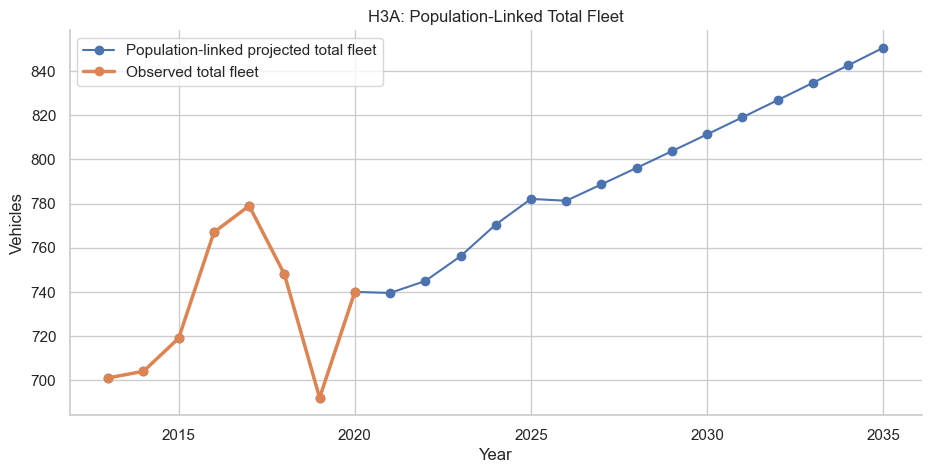

In [9]:
fig, ax = plt.subplots()
selected['projected_counts']['total_vehicles'].plot(ax=ax, marker='o', label='Population-linked projected total fleet')
selected['fleet_hist']['total_vehicles'].plot(ax=ax, marker='o', linewidth=2.5, label='Observed total fleet')
ax.set_title(f'{TARGET_FSA}: Population-Linked Total Fleet')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend()
plt.show()

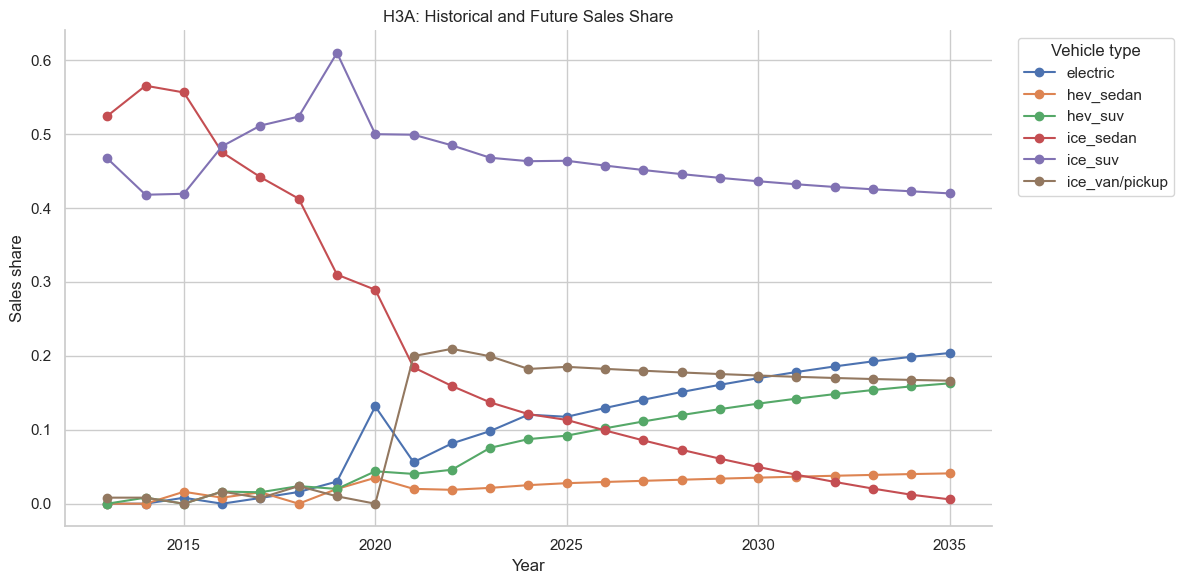

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
selected['sales_share_future'][vehicle_cols].plot(ax=ax, marker='o')
ax.set_title(f'{TARGET_FSA}: Historical and Future Sales Share')
ax.set_xlabel('Year')
ax.set_ylabel('Sales share')
ax.legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

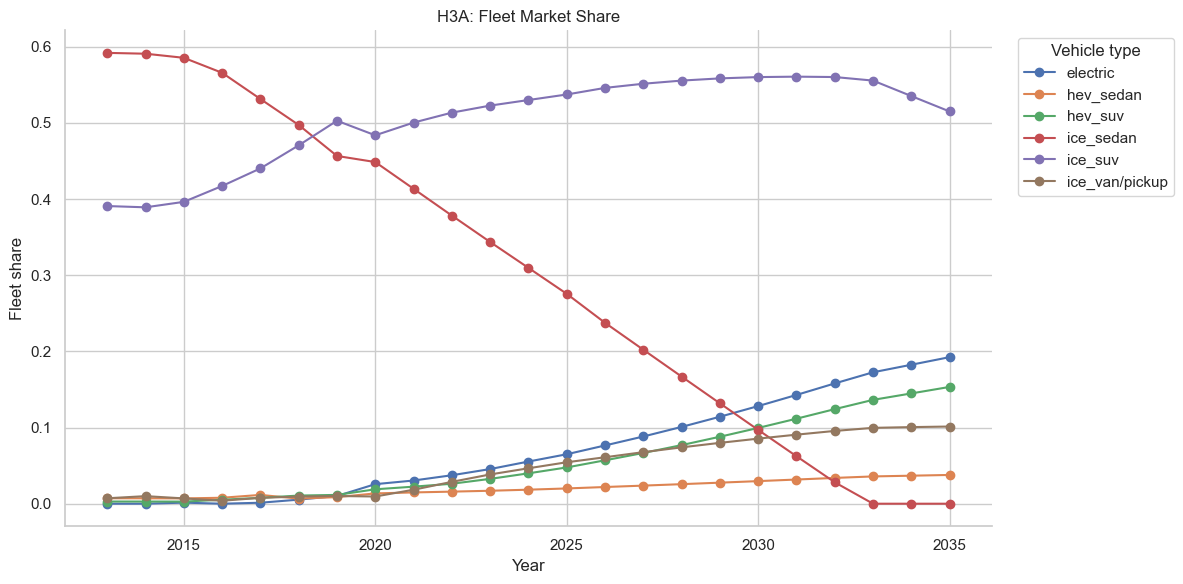

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
selected['projected_market_share'][vehicle_cols].plot(ax=ax, marker='o')
ax.set_title(f'{TARGET_FSA}: Fleet Market Share')
ax.set_xlabel('Year')
ax.set_ylabel('Fleet share')
ax.legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

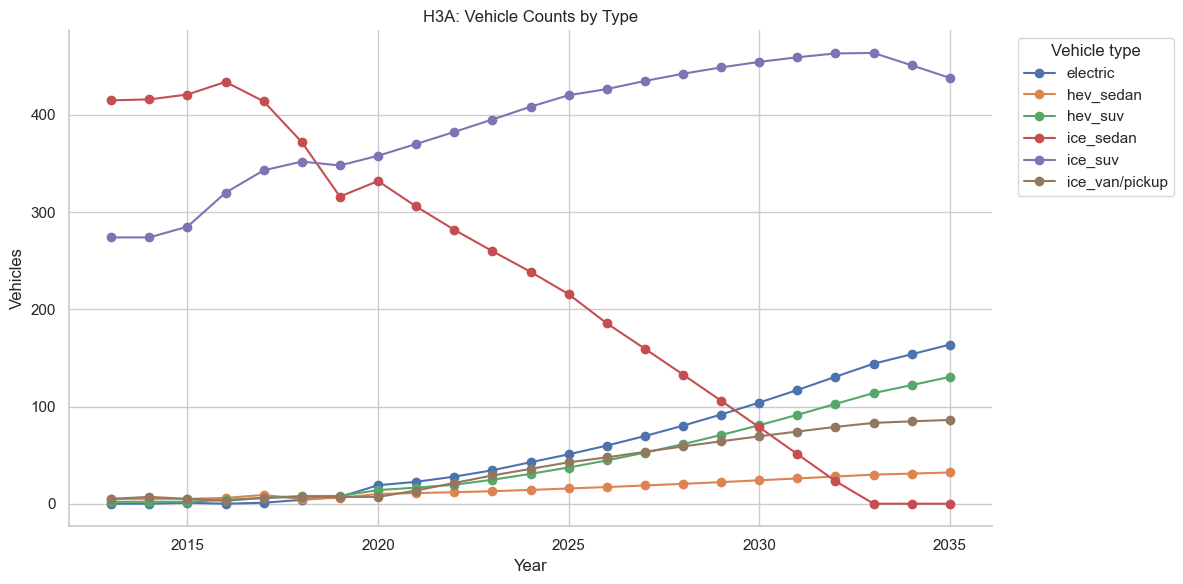

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
selected['projected_counts'][vehicle_cols].plot(ax=ax, marker='o')
ax.set_title(f'{TARGET_FSA}: Vehicle Counts by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend(title='Vehicle type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

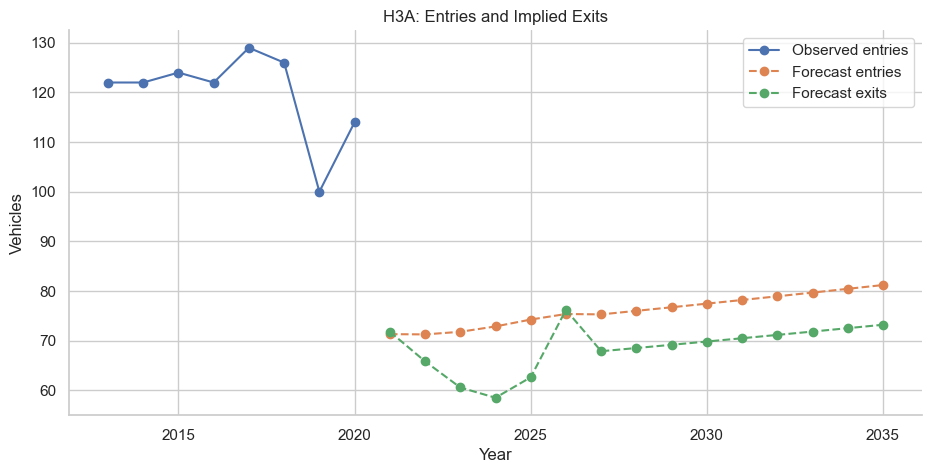

In [13]:
fig, ax = plt.subplots()
selected['entry_hist']['total_entries'].plot(ax=ax, marker='o', label='Observed entries')
if not selected['projection_summary'].empty:
    selected['projection_summary'].set_index('year')['entries'].plot(ax=ax, linestyle='--', marker='o', label='Forecast entries')
    selected['projection_summary'].set_index('year')['exits'].plot(ax=ax, linestyle='--', marker='o', label='Forecast exits')
ax.set_title(f'{TARGET_FSA}: Entries and Implied Exits')
ax.set_xlabel('Year')
ax.set_ylabel('Vehicles')
ax.legend()
plt.show()

## Step 8: Run the Model for All FSAs

Now we apply the same logic to every FSA in the cache.

The main outputs are:

- a summary table by FSA,
- a long table of projected market share by FSA and year,
- and diagnostics that show which FSAs are driven more by local data versus provincial shrinkage.

In [14]:
all_results = {}
summary_rows = []
market_rows = []
count_rows = []

for fsa in sorted(fsa_fleet.index.get_level_values('fsa').unique()):
    result = run_fsa_population_linked_model(
        fsa,
        fsa_fleet=fsa_fleet,
        fsa_entry=fsa_entry,
        fsa_exit=fsa_exit,
        province_entry_share_future=province_entry_share_future,
        province_exit_share_future=province_exit_share_future,
        province_target_total_fleet=province_target_total_fleet,
        province_turnover_rate=province_turnover_rate,
        vehicle_cols=vehicle_cols,
        forecast_end_year=FORECAST_END_YEAR,
        share_delta_clip=SHARE_DELTA_CLIP,
        shrinkage_k=SHRINKAGE_K,
        fsa_share_window=FSA_SHARE_WINDOW,
    )
    all_results[fsa] = result
    diag = result['diagnostics'].copy()
    diag['sparse_fsa_flag'] = diag['avg_entries_per_year'] < MIN_AVG_ENTRIES_FOR_FLAG
    market_share = result['projected_market_share']
    counts = result['projected_counts']
    for year in [2021, FORECAST_END_YEAR]:
        if year in market_share.index:
            diag[f'electric_fleet_share_{year}'] = float(market_share.loc[year, 'electric'])
            diag[f'electric_sales_share_{year}'] = float(result['sales_share_future'].loc[year, 'electric'])
            diag[f'total_fleet_{year}'] = float(counts.loc[year, 'total_vehicles'])
    if 2021 in market_share.index and FORECAST_END_YEAR in market_share.index:
        diag['electric_share_change_2021_to_2035'] = float(market_share.loc[FORECAST_END_YEAR, 'electric'] - market_share.loc[2021, 'electric'])
    summary_rows.append(diag)

    market_reset = market_share.reset_index()
    market_reset = market_reset.rename(columns={'index': 'year', 'AnneeSAAQ': 'year'})
    market_reset.insert(0, 'fsa', fsa)
    market_rows.append(market_reset)

    count_reset = counts.reset_index()
    count_reset = count_reset.rename(columns={'index': 'year', 'AnneeSAAQ': 'year'})
    count_reset.insert(0, 'fsa', fsa)
    count_rows.append(count_reset)

fsa_summary = pd.DataFrame(summary_rows).sort_values('electric_share_change_2021_to_2035', ascending=False)
fsa_forecast_market_share = pd.concat(market_rows, ignore_index=True)
fsa_forecast_counts = pd.concat(count_rows, ignore_index=True)

fsa_summary.head(10)

,fsa,avg_entries_per_year,shrinkage_weight,stable_fsa_share,last_observed_total,projected_2035_total,sparse_fsa_flag,electric_fleet_share_2021,electric_sales_share_2021,total_fleet_2021,electric_fleet_share_2035,electric_sales_share_2035,total_fleet_2035,electric_share_change_2021_to_2035
487,J7W,620.000,0.553571,0.001956,9171.0,10658.357179,False,0.018562,0.061720,9265.710513,0.233067,0.198640,10658.357179,0.214505
243,H3R,546.125,0.522046,0.000992,4534.0,5404.808194,False,0.033560,0.075329,4698.602914,0.231606,0.225285,5404.808194,0.198046
382,J2L,560.500,0.528524,0.001485,7366.0,8089.314650,False,0.034666,0.087016,7032.345280,0.222319,0.228146,8089.314650,0.187653
478,J7K,2110.625,0.808475,0.004824,22769.0,26277.805066,False,0.026805,0.083147,22844.283653,0.210098,0.197337,26277.805066,0.183293
408,J3V,1440.000,0.742268,0.003384,15746.0,18437.042850,False,0.032165,0.084361,16028.014346,0.214457,0.211973,18437.042850,0.182292
398,J3H,1398.375,0.736617,0.003586,16847.0,19533.136061,False,0.030643,0.093944,16980.889373,0.212923,0.218568,19533.136061,0.182280
424,J4R,425.625,0.459824,0.001157,5354.0,6301.913398,False,0.028692,0.075953,5478.490188,0.201824,0.223967,6301.913398,0.173132
233,H3C,553.250,0.525279,0.001131,5539.0,6163.387179,False,0.023805,0.059490,5358.064139,0.195171,0.182492,6163.387179,0.171366
472,J7B,898.750,0.642538,0.001735,8045.0,9453.838602,False,0.029782,0.077704,8218.577240,0.200593,0.198680,9453.838602,0.170811
443,J5R,2549.875,0.836059,0.006168,29158.0,33603.336762,False,0.027568,0.086512,29212.643702,0.197575,0.198443,33603.336762,0.170007


## Step 9: Portfolio Diagnostics Across FSAs

These diagnostics help interpret the FSA results more carefully.

Recommended reading:

- high EV growth with **high shrinkage weight** is more locally driven,
- high EV growth with **low shrinkage weight** is mostly the province-level signal,
- small FSAs should usually lean more on the province benchmark.

In [15]:
fsa_summary[['fsa', 'avg_entries_per_year', 'shrinkage_weight', 'stable_fsa_share', 'sparse_fsa_flag', 'electric_fleet_share_2021', 'electric_fleet_share_2035', 'electric_share_change_2021_to_2035']].head(20)

,fsa,avg_entries_per_year,shrinkage_weight,stable_fsa_share,sparse_fsa_flag,electric_fleet_share_2021,electric_fleet_share_2035,electric_share_change_2021_to_2035
487,J7W,620.000,0.553571,0.001956,False,0.018562,0.233067,0.214505
243,H3R,546.125,0.522046,0.000992,False,0.033560,0.231606,0.198046
382,J2L,560.500,0.528524,0.001485,False,0.034666,0.222319,0.187653
478,J7K,2110.625,0.808475,0.004824,False,0.026805,0.210098,0.183293
408,J3V,1440.000,0.742268,0.003384,False,0.032165,0.214457,0.182292
398,J3H,1398.375,0.736617,0.003586,False,0.030643,0.212923,0.182280
424,J4R,425.625,0.459824,0.001157,False,0.028692,0.201824,0.173132
233,H3C,553.250,0.525279,0.001131,False,0.023805,0.195171,0.171366
472,J7B,898.750,0.642538,0.001735,False,0.029782,0.200593,0.170811
443,J5R,2549.875,0.836059,0.006168,False,0.027568,0.197575,0.170007


/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


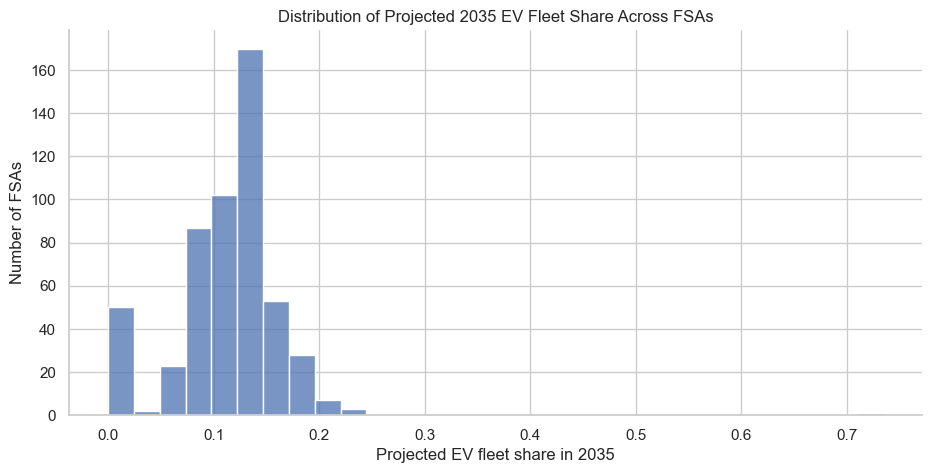

In [16]:
fig, ax = plt.subplots()
sns.histplot(fsa_summary['electric_fleet_share_2035'], bins=30, ax=ax)
ax.set_title('Distribution of Projected 2035 EV Fleet Share Across FSAs')
ax.set_xlabel('Projected EV fleet share in 2035')
ax.set_ylabel('Number of FSAs')
plt.show()

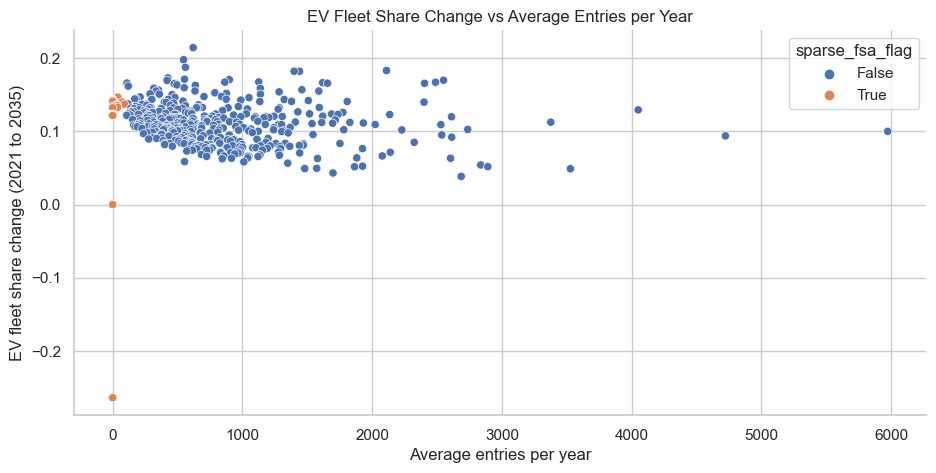

In [17]:
fig, ax = plt.subplots()
sns.scatterplot(data=fsa_summary, x='avg_entries_per_year', y='electric_share_change_2021_to_2035', hue='sparse_fsa_flag', ax=ax)
ax.set_title('EV Fleet Share Change vs Average Entries per Year')
ax.set_xlabel('Average entries per year')
ax.set_ylabel('EV fleet share change (2021 to 2035)')
plt.show()

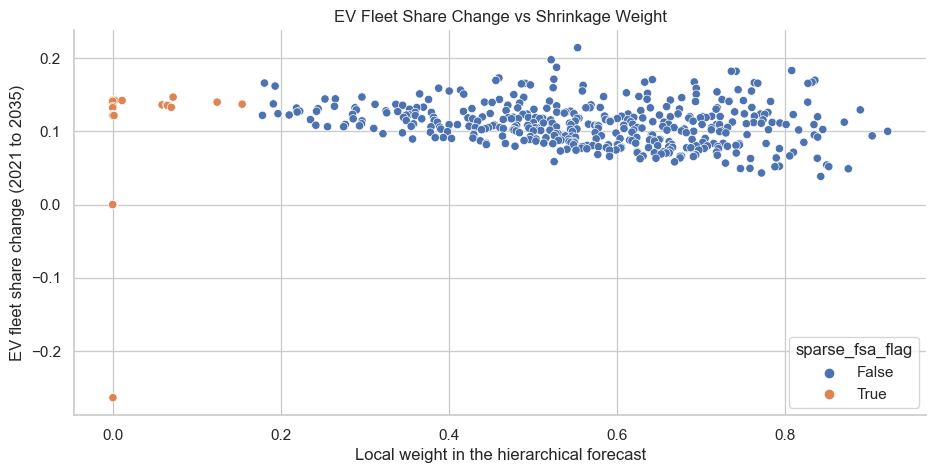

In [18]:
fig, ax = plt.subplots()
sns.scatterplot(data=fsa_summary, x='shrinkage_weight', y='electric_share_change_2021_to_2035', hue='sparse_fsa_flag', ax=ax)
ax.set_title('EV Fleet Share Change vs Shrinkage Weight')
ax.set_xlabel('Local weight in the hierarchical forecast')
ax.set_ylabel('EV fleet share change (2021 to 2035)')
plt.show()

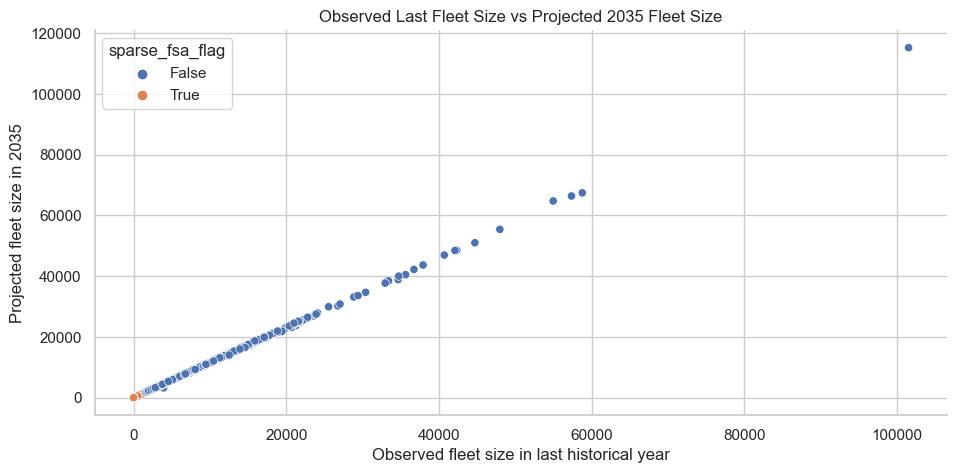

In [19]:
fig, ax = plt.subplots()
sns.scatterplot(data=fsa_summary, x='last_observed_total', y='projected_2035_total', hue='sparse_fsa_flag', ax=ax)
ax.set_title('Observed Last Fleet Size vs Projected 2035 Fleet Size')
ax.set_xlabel('Observed fleet size in last historical year')
ax.set_ylabel('Projected fleet size in 2035')
plt.show()

## Optional: Compare Several FSAs Directly

Edit the list below and rerun if you want to compare specific postal areas.

In [20]:
COMPARE_FSAS = ['H3A', 'H2X', 'G1K', 'J7V']
comparison_rows = []
for fsa in COMPARE_FSAS:
    if fsa in all_results:
        share = all_results[fsa]['projected_market_share']['electric']
        for year, value in share.items():
            comparison_rows.append({'fsa': fsa, 'year': year, 'electric_fleet_share': float(value)})
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.head()

,fsa,year,electric_fleet_share
0,H3A,2013,0.000000
1,H3A,2014,0.000000
2,H3A,2015,0.001391
3,H3A,2016,0.000000
4,H3A,2017,0.001284


/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/natomanzolli/opt/anaconda

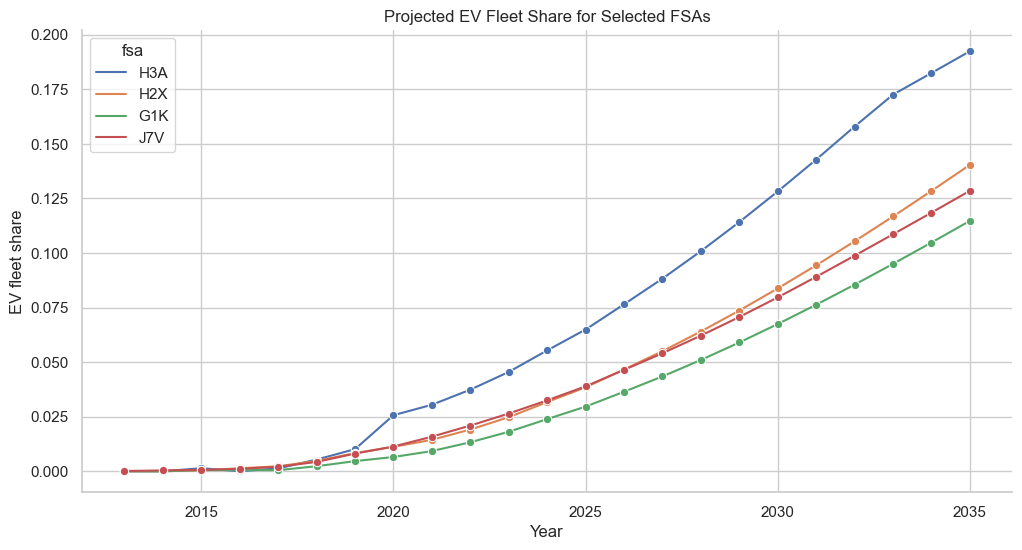

In [21]:
if not comparison_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=comparison_df, x='year', y='electric_fleet_share', hue='fsa', marker='o', ax=ax)
    ax.set_title('Projected EV Fleet Share for Selected FSAs')
    ax.set_xlabel('Year')
    ax.set_ylabel('EV fleet share')
    plt.show()

## Quebec City Evaluation

This section builds a more detailed view for Quebec City by aggregating the FSAs that start with `G1` or `G2`.

Why this is useful:

- it gives a cleaner local picture than looking at one FSA at a time,
- it reduces small-area noise,
- and it lets us compare sales-share change against fleet-share change for one metropolitan cluster.


In [22]:
QUEBEC_CITY_FSAS = sorted([f for f in all_results if str(f).startswith('G1') or str(f).startswith('G2')])
quebec_city_market = (
    fsa_forecast_counts[fsa_forecast_counts['fsa'].isin(QUEBEC_CITY_FSAS)]
    .groupby('year')[vehicle_cols + ['total_vehicles']]
    .sum()
)
quebec_city_market_share = quebec_city_market[vehicle_cols].div(quebec_city_market[vehicle_cols].sum(axis=1), axis=0).fillna(0)
quebec_city_sales_rows = []
for fsa in QUEBEC_CITY_FSAS:
    sales = all_results[fsa]['sales_share_future'][vehicle_cols].copy()
    entries_hist = all_results[fsa]['entry_hist']['total_entries'].reindex(sales.index).fillna(0)
    entries_future = all_results[fsa]['projection_summary'].set_index('year')['entries'] if not all_results[fsa]['projection_summary'].empty else pd.Series(dtype=float)
    entry_weights = entries_future.reindex(sales.index).combine_first(entries_hist).fillna(0)
    for year in sales.index:
        row = {'fsa': fsa, 'year': int(year), 'weight': float(entry_weights.loc[year])}
        for col in vehicle_cols:
            row[col] = float(sales.loc[year, col]) * row['weight']
        quebec_city_sales_rows.append(row)
quebec_city_sales_weighted = pd.DataFrame(quebec_city_sales_rows)
if quebec_city_sales_weighted.empty:
    quebec_city_sales_share = pd.DataFrame(0.0, index=quebec_city_market.index, columns=vehicle_cols)
else:
    qc_sales_num = quebec_city_sales_weighted.groupby('year')[vehicle_cols].sum()
    qc_sales_den = quebec_city_sales_weighted.groupby('year')['weight'].sum().replace(0, np.nan)
    quebec_city_sales_share = qc_sales_num.div(qc_sales_den, axis=0).fillna(0)
quebec_city_summary = pd.DataFrame({
    'sales_share_2021': quebec_city_sales_share.loc[2021],
    'sales_share_2035': quebec_city_sales_share.loc[2035],
    'fleet_share_2021': quebec_city_market_share.loc[2021],
    'fleet_share_2035': quebec_city_market_share.loc[2035],
    'count_2035': quebec_city_market.loc[2035, vehicle_cols],
}).sort_values('count_2035', ascending=False)
quebec_city_summary


,sales_share_2021,sales_share_2035,fleet_share_2021,fleet_share_2035,count_2035
ice_suv,0.545484,0.621833,0.442767,0.618426,188469.688371
electric,0.033187,0.111942,0.009457,0.099318,30267.856895
ice_van/pickup,0.129261,0.133090,0.049105,0.093327,28442.190572
hev_suv,0.031142,0.098924,0.010042,0.091299,27824.076614
ice_sedan,0.242003,0.004353,0.475760,0.064551,19672.213813
hev_sedan,0.018922,0.029857,0.012868,0.033078,10080.895873


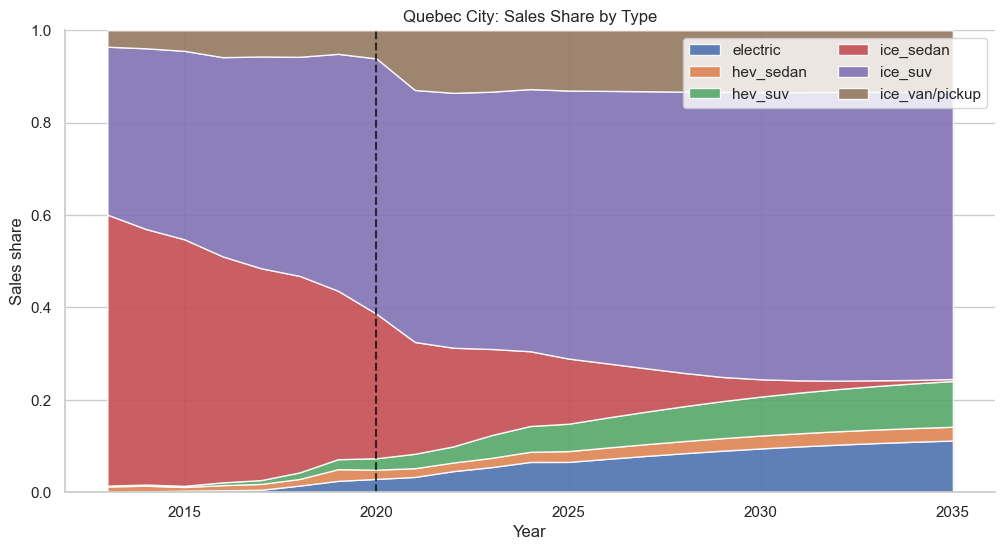

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(quebec_city_sales_share.index, [quebec_city_sales_share[col] for col in vehicle_cols], labels=vehicle_cols, alpha=0.9)
ax.axvline(last_observed_year, color='black', linestyle='--', alpha=0.7)
ax.set_title('Quebec City: Sales Share by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Sales share')
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc='upper right')
plt.show()


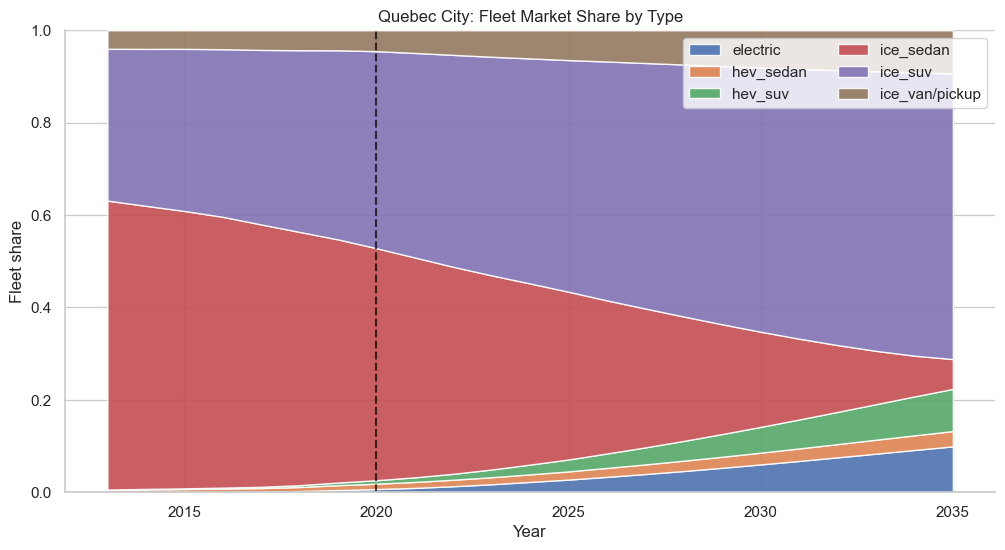

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(quebec_city_market_share.index, [quebec_city_market_share[col] for col in vehicle_cols], labels=vehicle_cols, alpha=0.9)
ax.axvline(last_observed_year, color='black', linestyle='--', alpha=0.7)
ax.set_title('Quebec City: Fleet Market Share by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Fleet share')
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc='upper right')
plt.show()


In [25]:
quebec_city_fsa_detail = fsa_summary[fsa_summary['fsa'].isin(QUEBEC_CITY_FSAS)][['fsa', 'avg_entries_per_year', 'shrinkage_weight', 'electric_fleet_share_2021', 'electric_fleet_share_2035', 'electric_share_change_2021_to_2035', 'projected_2035_total']].sort_values('electric_share_change_2021_to_2035', ascending=False)
quebec_city_fsa_detail.head(20)


,fsa,avg_entries_per_year,shrinkage_weight,electric_fleet_share_2021,electric_fleet_share_2035,electric_share_change_2021_to_2035,projected_2035_total
53,G2S,0.000,0.000000,0.002689,0.145382,0.142693,1.170618
20,G1A,0.375,0.000749,0.002666,0.145311,0.142645,3.523230
34,G1T,408.250,0.449491,0.026660,0.151188,0.124527,4306.445228
46,G2J,199.875,0.285587,0.008851,0.132131,0.123280,2211.777782
45,G2H,0.000,0.000000,0.002163,0.124196,0.122033,0.779428
33,G1S,987.625,0.663894,0.015685,0.135750,0.120065,12298.748086
32,G1R,452.000,0.474790,0.010614,0.127974,0.117360,5920.885573
49,G2M,315.125,0.386597,0.010158,0.122800,0.112642,3882.994545
30,G1N,210.500,0.296270,0.006103,0.116719,0.110617,3808.522448
38,G1Y,813.125,0.619229,0.019428,0.129257,0.109829,8985.596275


## Optional: Save Outputs

This cell exports the most useful FSA outputs:

- `fsa_population_linked_summary.csv`
- `fsa_population_linked_market_share.csv`
- `fsa_population_linked_counts.csv`

These tables are designed to match the logic of the current province-level calibrated model.

In [26]:
output_dir = PROJECT_DIR / 'validation_outputs' / 'fsa_replacement_dynamics_ev_calibrated_model'
output_dir.mkdir(parents=True, exist_ok=True)

fsa_summary.to_csv(output_dir / 'fsa_population_linked_summary.csv', index=False)
fsa_forecast_market_share.to_csv(output_dir / 'fsa_population_linked_market_share.csv', index=False)
fsa_forecast_counts.to_csv(output_dir / 'fsa_population_linked_counts.csv', index=False)
comparison_df.to_csv(output_dir / 'selected_fsa_ev_comparison.csv', index=False)
quebec_city_summary.to_csv(output_dir / 'quebec_city_summary.csv')
quebec_city_fsa_detail.to_csv(output_dir / 'quebec_city_fsa_detail.csv', index=False)

if not comparison_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=comparison_df, x='year', y='electric_fleet_share', hue='fsa', marker='o', ax=ax)
    ax.set_title('Selected FSAs: EV Fleet Share')
    ax.set_xlabel('Year')
    ax.set_ylabel('EV fleet share')
    fig.tight_layout()
    fig.savefig(output_dir / 'selected_fsa_ev_fleet_share.png', dpi=200, bbox_inches='tight')
    plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(quebec_city_sales_share.index, [quebec_city_sales_share[col] for col in vehicle_cols], labels=vehicle_cols, alpha=0.9)
ax.axvline(last_observed_year, color='black', linestyle='--', alpha=0.7)
ax.set_title('Quebec City: Sales Share by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Sales share')
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc='upper right')
fig.tight_layout()
fig.savefig(output_dir / 'quebec_city_sales_share.png', dpi=200, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(quebec_city_market_share.index, [quebec_city_market_share[col] for col in vehicle_cols], labels=vehicle_cols, alpha=0.9)
ax.axvline(last_observed_year, color='black', linestyle='--', alpha=0.7)
ax.set_title('Quebec City: Fleet Market Share by Type')
ax.set_xlabel('Year')
ax.set_ylabel('Fleet share')
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc='upper right')
fig.tight_layout()
fig.savefig(output_dir / 'quebec_city_fleet_market_share.png', dpi=200, bbox_inches='tight')
plt.close(fig)

output_dir


/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/natomanzolli/opt/anaconda

PosixPath('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/fsa_replacement_dynamics_ev_calibrated_model')

## Summary

This notebook applies the same calibrated replacement-dynamics idea at the FSA level, but with one essential protection: **hierarchical shrinkage**.

### What makes it different from the older FSA notebook

- total fleet is now linked to the **province-level population path**,
- sales share is anchored to the **province-level calibrated market benchmark**,
- local FSAs keep their own structure only to the extent supported by local entry volume.

### Why this is the right direction

This version is much more defensible because it separates:

- **province-level stability**, and
- **FSA-level heterogeneity**.

That is exactly what we need when local data becomes sparse.